In [2]:
!pip install tensorflow numpy opencv-python matplotlib scikit-learn seaborn pillow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Basic libraries
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Evaluation libraries
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
TRAINING_PATH = r"D:\Healthcare Scan Assessment Platform\Datasets\training"
TESTING_PATH = r"D:\Healthcare Scan Assessment Platform\Datasets\testing"

print("Training Path:", TRAINING_PATH)
print("Testing Path:", TESTING_PATH)

# Verify dataset folders exist
if not os.path.exists(TRAINING_PATH):
    print("Training folder not found!")

if not os.path.exists(TESTING_PATH):
    print("Testing folder not found!")

Training Path: D:\Healthcare Scan Assessment Platform\Datasets\training
Testing Path: D:\Healthcare Scan Assessment Platform\Datasets\testing


In [6]:
import os

# Dataset path
DATASET_PATH = r"D:\Healthcare Scan Assessment Platform\Datasets"

# Train folder path
TRAINING_PATH = os.path.join(DATASET_PATH, "training")

# Check dataset
if os.path.exists(TRAINING_PATH):
    print("Dataset folder found!")

    # List all disease classes
    classes = os.listdir(TRAINING_PATH)

    print("Classes found in dataset:")

    for c in classes:
        print("-", c)

else:
    print("Training folder NOT found. Check the path.")

Dataset folder found!
Classes found in dataset:
- bone_fractured
- bone_not_fractured
- brain_glioma
- brain_meningioma
- brain_no_tumor
- brain_pituitary
- chest_NORMAL
- chest_PNEUMONIA
- kidney_Cyst
- kidney_Normal
- kidney_Stone
- kidney_Tumor
- liver_Cirrhosis
- liver_No_Fibrosis
- liver_Periportal_Fibrosis
- liver_Portal_Fibrosis
- liver_Septal_Fibrosis


In [7]:
import os

DATASET_PATH = r"D:\Healthcare Scan Assessment Platform\Datasets"

print("Counting images in each disease...\n")

for dataset_type in ["training", "testing"]:

    dataset_folder = os.path.join(DATASET_PATH, dataset_type)

    print(f"\n{dataset_type.upper()} DATASET")

    for disease in os.listdir(dataset_folder):

        disease_path = os.path.join(dataset_folder, disease)

        if os.path.isdir(disease_path):

            image_count = len(os.listdir(disease_path))

            print(f"{disease}: {image_count} images")

Counting images in each disease...


TRAINING DATASET
bone_fractured: 4480 images
bone_not_fractured: 4383 images
brain_glioma: 826 images
brain_meningioma: 822 images
brain_no_tumor: 395 images
brain_pituitary: 827 images
chest_NORMAL: 1349 images
chest_PNEUMONIA: 3883 images
kidney_Cyst: 2962 images
kidney_Normal: 4060 images
kidney_Stone: 1098 images
kidney_Tumor: 1824 images
liver_Cirrhosis: 1356 images
liver_No_Fibrosis: 1691 images
liver_Periportal_Fibrosis: 631 images
liver_Portal_Fibrosis: 690 images
liver_Septal_Fibrosis: 686 images

TESTING DATASET
bone_fractured: 360 images
bone_not_fractured: 240 images
brain_glioma: 100 images
brain_meningioma: 115 images
brain_no_tumor: 105 images
brain_pituitary: 74 images
chest_NORMAL: 234 images
chest_PNEUMONIA: 390 images
kidney_Cyst: 747 images
kidney_Normal: 1017 images
kidney_Stone: 279 images
kidney_Tumor: 459 images
liver_Cirrhosis: 342 images
liver_No_Fibrosis: 423 images
liver_Periportal_Fibrosis: 162 images
liver_Portal_Fibros

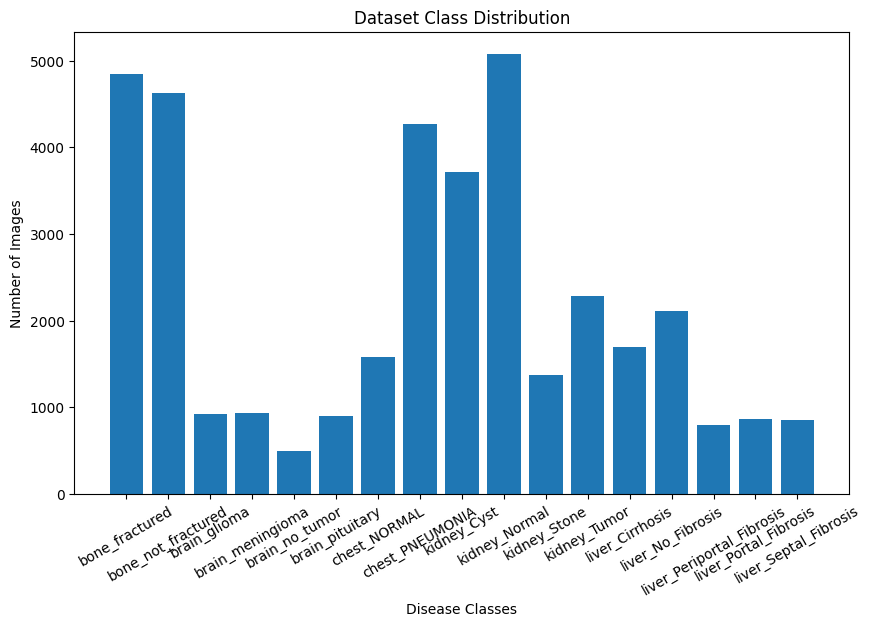

In [8]:
import os
import matplotlib.pyplot as plt

DATASET_PATH = r"D:\Healthcare Scan Assessment Platform\Datasets"

classes = []
counts = []

for dataset_type in ["training", "testing"]:

    dataset_folder = os.path.join(DATASET_PATH, dataset_type)

    for disease in os.listdir(dataset_folder):

        disease_path = os.path.join(dataset_folder, disease)

        if os.path.isdir(disease_path):

            image_count = len(os.listdir(disease_path))

            if disease in classes:
                index = classes.index(disease)
                counts[index] += image_count
            else:
                classes.append(disease)
                counts.append(image_count)

# Plot bar chart
plt.figure(figsize=(10,6))
plt.bar(classes, counts)

plt.title("Dataset Class Distribution")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.show()

In [9]:
import os

DATASET_PATH = r"D:\Healthcare Scan Assessment Platform\Datasets"

class_counts = {}

for root, dirs, files in os.walk(DATASET_PATH):

    image_files = [f for f in files if f.lower().endswith(('.png','.jpg','.jpeg'))]

    if len(image_files) > 0:

        class_name = os.path.basename(root)

        if class_name in class_counts:
            class_counts[class_name] += len(image_files)
        else:
            class_counts[class_name] = len(image_files)

print(class_counts)

{'bone_fractured': 4840, 'bone_not_fractured': 4623, 'brain_glioma': 926, 'brain_meningioma': 937, 'brain_no_tumor': 500, 'brain_pituitary': 901, 'chest_NORMAL': 1583, 'chest_PNEUMONIA': 4273, 'kidney_Cyst': 3709, 'kidney_Normal': 5077, 'kidney_Stone': 1377, 'kidney_Tumor': 2283, 'liver_Cirrhosis': 1698, 'liver_No_Fibrosis': 2114, 'liver_Periportal_Fibrosis': 793, 'liver_Portal_Fibrosis': 861, 'liver_Septal_Fibrosis': 857}


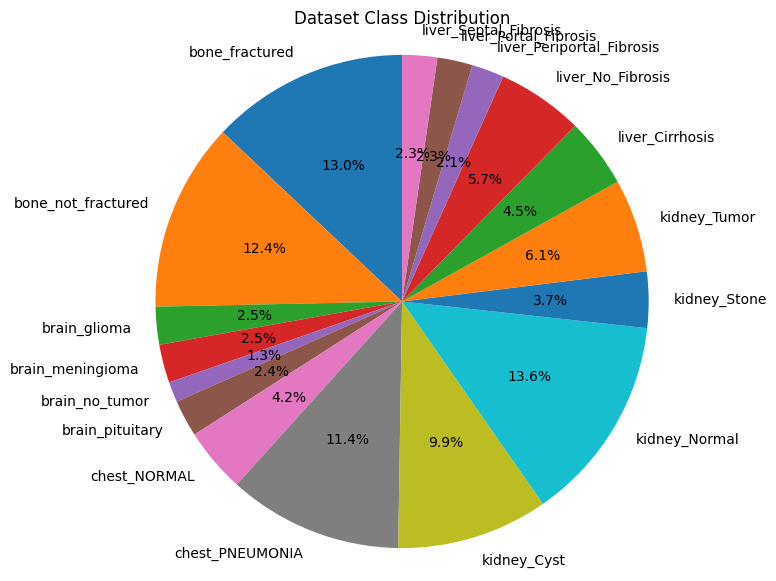

In [10]:
import matplotlib.pyplot as plt

# Get labels and counts
labels = list(class_counts.keys())
sizes = list(class_counts.values())

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Dataset Class Distribution")

plt.axis('equal')  # keeps pie chart circular

plt.show()

Total images found: 37352


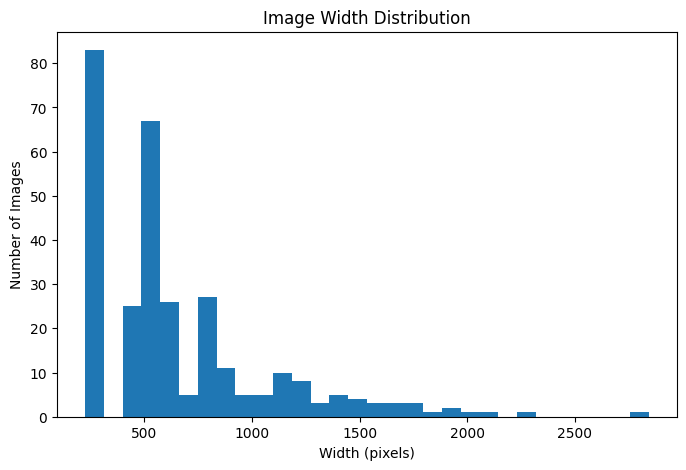

In [11]:
import cv2
import os
import random
import matplotlib.pyplot as plt

DATASET_PATH = r"D:\Healthcare Scan Assessment Platform\Datasets"

widths = []
heights = []
image_paths = []

# Collect image paths
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(('.png','.jpg','.jpeg')):
            image_paths.append(os.path.join(root,file))

print("Total images found:", len(image_paths))

# Take random sample (faster)
sample_paths = random.sample(image_paths, min(300, len(image_paths)))

# Read images
for path in sample_paths:
    img = cv2.imread(path)

    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

# Plot histogram
plt.figure(figsize=(8,5))

plt.hist(widths, bins=30)

plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of Images")

plt.show()

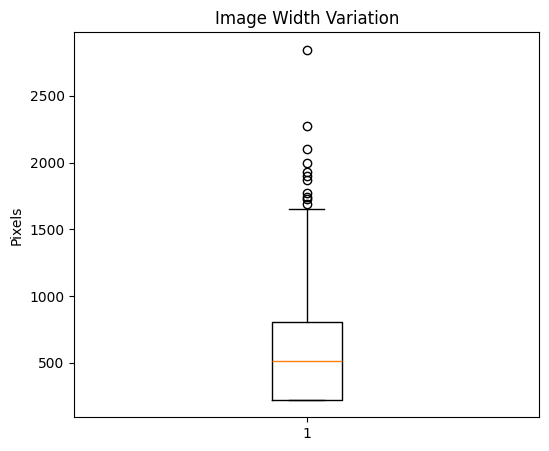

In [12]:
plt.figure(figsize=(6,5))

plt.boxplot(widths)

plt.title("Image Width Variation")
plt.ylabel("Pixels")

plt.show()

ValueError: num must be an integer with 1 <= num <= 9, not 10

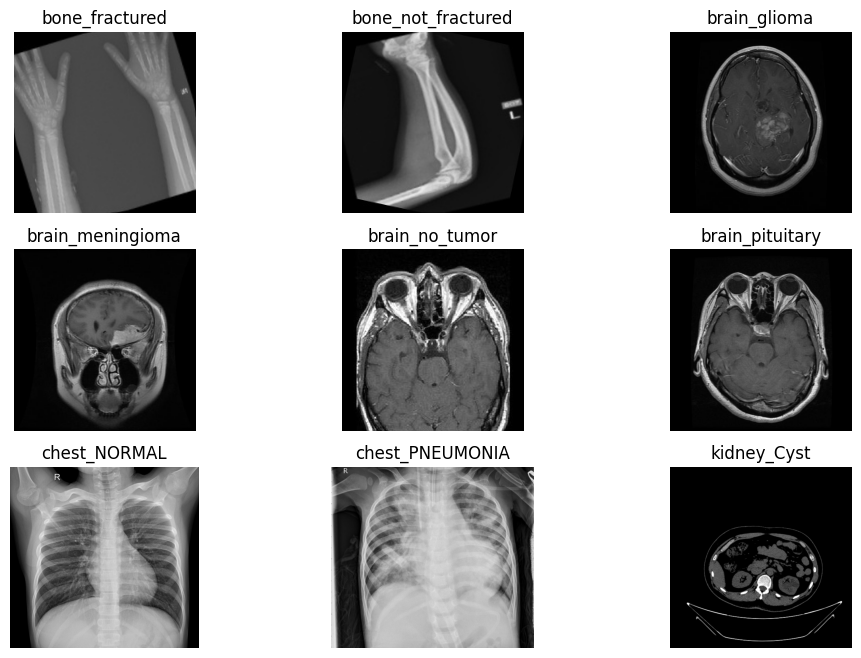

In [13]:
import os
import cv2
import matplotlib.pyplot as plt

training_path = r"D:\Healthcare Scan Assessment Platform\Datasets\training"

classes = os.listdir(training_path)

plt.figure(figsize=(12,8))

for i, disease in enumerate(classes, start=1):

    disease_path = os.path.join(training_path, disease)

    if os.path.isdir(disease_path):

        img_name = os.listdir(disease_path)[0]
        img_path = os.path.join(disease_path, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(3,3,i)
        plt.imshow(img)
        plt.title(disease)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
import os
from PIL import Image

DATASET_PATH = r"D:\Healthcare Scan Assessment Platform\Datasets"

corrupted_count = 0

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith(('.png','.jpg','.jpeg')):

            file_path = os.path.join(root, file)

            try:
                with Image.open(file_path) as img:
                    img.verify()   # verify image

            except Exception as e:
                print("Removing corrupted image:", file_path)
                os.remove(file_path)
                corrupted_count += 1

print("Total corrupted images removed:", corrupted_count)

Total corrupted images removed: 0


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAINING_PATH = r"D:\Healthcare Scan Assessment Platform\Datasets\training"

IMG_SIZE = (128,128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

training_data = datagen.flow_from_directory(
    TRAINING_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    TRAINING_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Number of Classes:", training_data.num_classes)
print("Class Labels:", training_data.class_indices)

Found 25576 images belonging to 17 classes.
Found 6387 images belonging to 17 classes.
Number of Classes: 17
Class Labels: {'bone_fractured': 0, 'bone_not_fractured': 1, 'brain_glioma': 2, 'brain_meningioma': 3, 'brain_no_tumor': 4, 'brain_pituitary': 5, 'chest_NORMAL': 6, 'chest_PNEUMONIA': 7, 'kidney_Cyst': 8, 'kidney_Normal': 9, 'kidney_Stone': 10, 'kidney_Tumor': 11, 'liver_Cirrhosis': 12, 'liver_No_Fibrosis': 13, 'liver_Periportal_Fibrosis': 14, 'liver_Portal_Fibrosis': 15, 'liver_Septal_Fibrosis': 16}


In [17]:
IMG_SIZE = 224
BATCH_SIZE = 32

training_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

testing_datagen = ImageDataGenerator(rescale=1./255)

In [18]:
print("Number of Classes:", training_data.num_classes)
print("Class Labels:", training_data.class_indices)

Number of Classes: 17
Class Labels: {'bone_fractured': 0, 'bone_not_fractured': 1, 'brain_glioma': 2, 'brain_meningioma': 3, 'brain_no_tumor': 4, 'brain_pituitary': 5, 'chest_NORMAL': 6, 'chest_PNEUMONIA': 7, 'kidney_Cyst': 8, 'kidney_Normal': 9, 'kidney_Stone': 10, 'kidney_Tumor': 11, 'liver_Cirrhosis': 12, 'liver_No_Fibrosis': 13, 'liver_Periportal_Fibrosis': 14, 'liver_Portal_Fibrosis': 15, 'liver_Septal_Fibrosis': 16}


In [19]:
training_generator = training_datagen.flow_from_directory(
    TRAINING_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 25576 images belonging to 17 classes.


In [20]:
val_generator = training_datagen.flow_from_directory(
    TRAINING_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 6387 images belonging to 17 classes.


In [21]:
testing_generator = testing_datagen.flow_from_directory(
    TESTING_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5389 images belonging to 17 classes.


In [22]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

In [23]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [24]:
for layer in base_model.layers:
    layer.trainable = False

In [25]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(17, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [26]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,590,289 (9.88 MB)

 Trainable params: 332,305 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
EPOCHS = 10

history = model.fit(
    training_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 731s 910ms/step - accuracy: 0.6030 - loss: 1.0609 - val_accuracy: 0.6599 - val_loss: 0.7913
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 751s 939ms/step - accuracy: 0.7399 - loss: 0.6411 - val_accuracy: 0.6682 - val_loss: 0.7531
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 743s 929ms/step - accuracy: 0.7884 - loss: 0.5348 - val_accuracy: 0.6689 - val_loss: 0.7477
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 737s 921ms/step - accuracy: 0.8161 - loss: 0.4668 - val_accuracy: 0.6919 - val_loss: 0.7241
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 733s 916ms/step - accuracy: 0.8354 - loss: 0.4243 - val_accuracy: 0.6844 - val_loss: 0.7119
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 859s 1s/step - accuracy: 0.8486 - loss: 0.3907 - val_accuracy: 0.7019 - val_loss: 0.7061
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 785s 982ms/step - accuracy: 0.8623 - loss: 0.3604 - val_accuracy: 0.7021 - val_loss: 0.7100
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 802s 1s/step - accuracy: 0.8707 - loss:

In [29]:
model.save("models/healthcare_model.keras")

In [30]:
for layer in base_model.layers[-40:]:
    layer.trainable = True

In [31]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.fit(
    training_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 1354s 2s/step - accuracy: 0.8019 - loss: 0.5220 - val_accuracy: 0.7036 - val_loss: 0.7871
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 1348s 2s/step - accuracy: 0.8669 - loss: 0.3418 - val_accuracy: 0.7332 - val_loss: 0.7156
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 1001s 1s/step - accuracy: 0.8916 - loss: 0.2807 - val_accuracy: 0.7453 - val_loss: 0.7034
Epoch 4/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 1145s 1s/step - accuracy: 0.9072 - loss: 0.2440 - val_accuracy: 0.7321 - val_loss: 0.7746
Epoch 5/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 1094s 1s/step - accuracy: 0.9144 - loss: 0.2155 - val_accuracy: 0.7418 - val_loss: 0.7508


In [2]:


from tensorflow.keras.models import load_model

model = load_model("Backend/healthcare_model.keras")

model.save("Backend/model.h5")

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

testing_datagen = ImageDataGenerator(rescale=1./255)

testing_generator = testing_datagen.flow_from_directory(
    'Datasets/testing',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5389 images belonging to 17 classes.


In [5]:
Y_pred = model.predict(testing_generator)

169/169 ━━━━━━━━━━━━━━━━━━━━ 88s 516ms/step


In [6]:
import numpy as np

Y_pred = model.predict(testing_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = testing_generator.classes

169/169 ━━━━━━━━━━━━━━━━━━━━ 87s 515ms/step


In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[272  88   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 89 151   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0  25  47  14  14   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   3  83  13  16   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   7   6  83   6   0   0   3   0   0   0   0   0   0   0   0]
 [  0   0   0   7   9  58   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 182  52   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   5 385   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 701   0  46   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  91 808 118   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  33  14 232   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  92 218  49 100   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 320   9   3   3   7]
 [  0   0   0   0   0   0   0   0   0   0   0   0  17 406   0   0   0]
 [  0 

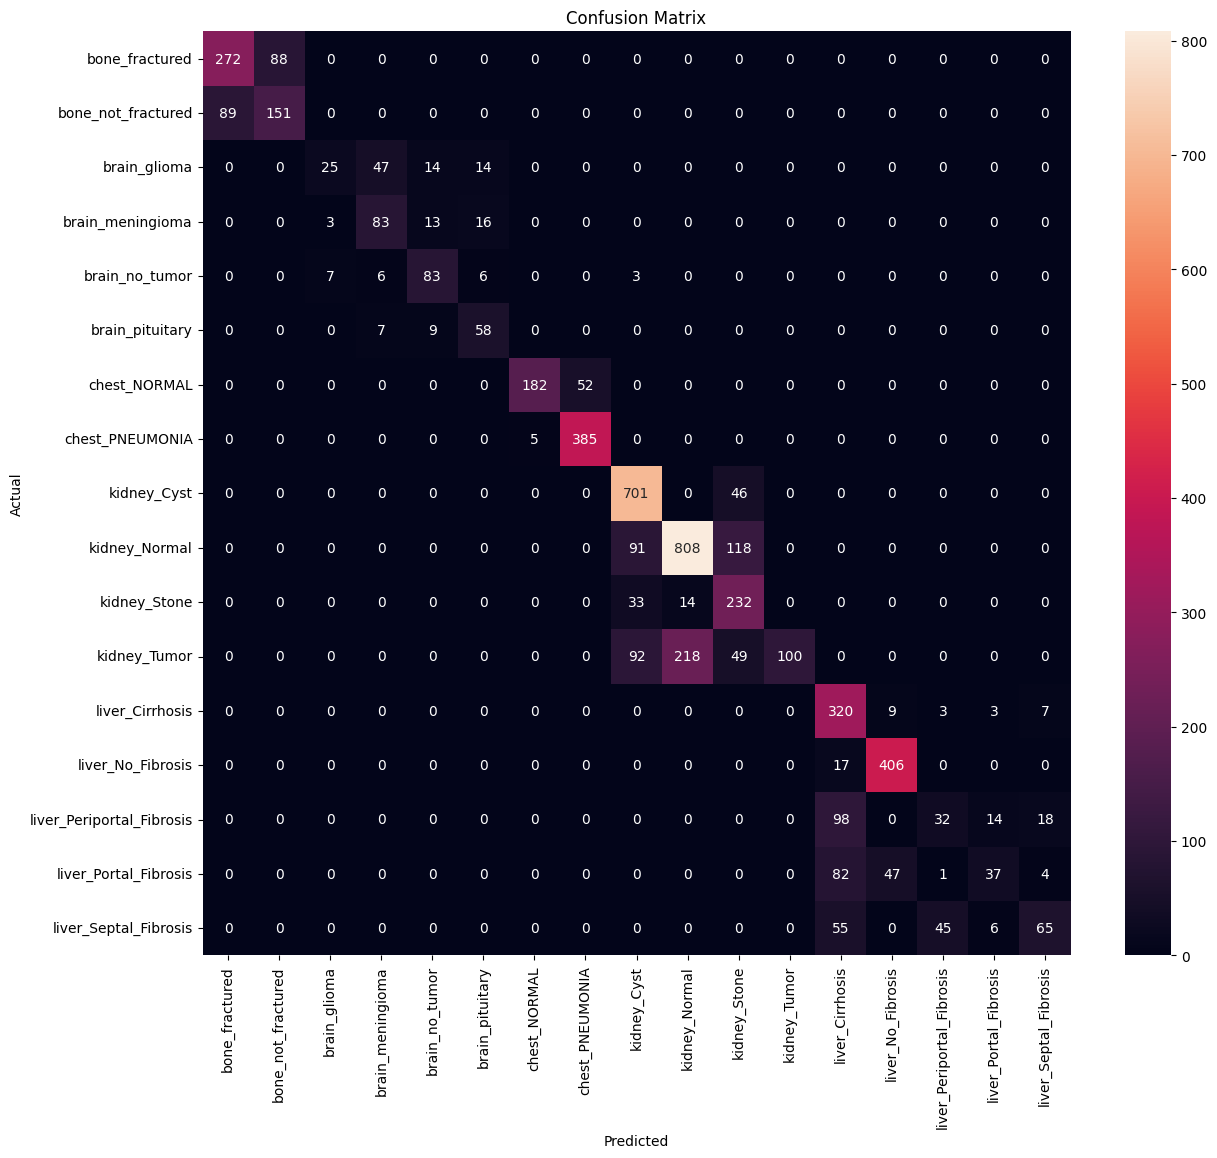

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = list(testing_generator.class_indices.keys())

plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                           precision    recall  f1-score   support

           bone_fractured       0.75      0.76      0.75       360
       bone_not_fractured       0.63      0.63      0.63       240
             brain_glioma       0.71      0.25      0.37       100
         brain_meningioma       0.58      0.72      0.64       115
           brain_no_tumor       0.70      0.79      0.74       105
          brain_pituitary       0.62      0.78      0.69        74
             chest_NORMAL       0.97      0.78      0.86       234
          chest_PNEUMONIA       0.88      0.99      0.93       390
              kidney_Cyst       0.76      0.94      0.84       747
            kidney_Normal       0.78      0.79      0.79      1017
             kidney_Stone       0.52      0.83      0.64       279
             kidney_Tumor       1.00      0.22      0.36       459
          liver_Cirrhosis       0.56      0.94      0.70       342
        liver_No_Fibrosis       0.88      0.96      0.92     

In [10]:
from IPython.display import display
from ipywidgets import FileUpload

uploader = FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

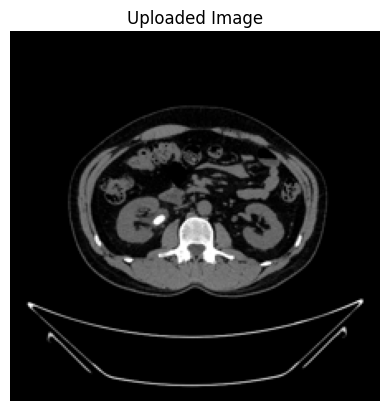

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Prediction: Kidney Stone
Confidence: 74.31 %


In [16]:
import matplotlib.pyplot as plt

if uploader.value:
    file_info = uploader.value[0]   # for PyCharm tuple fix
    content = file_info['content']

    from PIL import Image
    import io
    import numpy as np

    # Convert to image
    img = Image.open(io.BytesIO(content)).convert('RGB')
    img = img.resize((224, 224))

    plt.imshow(img)
    plt.title("Uploaded Image")
    plt.axis('off')
    plt.show()

    # Preprocess
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]
    confidence = float(np.max(prediction)) * 100


    print("Prediction:", predicted_class.replace('_',' ').title())
    print("Confidence:", round(confidence, 2), "%")

else:
    print("⚠️ Please upload image first")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("healthcare_model.keras")

model.save("model.h5")